# Training Results Visualization

This notebook visualizes the evaluation results from training experiments.

**Terminology:**
- **Validation perplexity** (`val_perplexity`): Computed on the small validation set used for data selection (n_val samples, e.g., 5)
- **Evaluation perplexity** (`eval_perplexity`): Computed on the large held-out evaluation set for measuring generalization (n_eval samples, e.g., 500)

The results are saved in `evaluation_results.json` files during training.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

## Load Results

In [2]:
def load_results(result_path):
    """
    Load evaluation results from JSON file.

    Args:
        result_path: Path to evaluation_results.json

    Returns:
        dict with steps, val_perplexity, eval_perplexity arrays
    """
    with open(result_path, 'r') as f:
        data = json.load(f)

    steps = [item['step'] for item in data]
    val_perplexity = [item['val_perplexity'] for item in data]
    eval_perplexity = [item['eval_perplexity'] for item in data]

    return {
        'steps': np.array(steps),
        'val_perplexity': np.array(val_perplexity),
        'eval_perplexity': np.array(eval_perplexity),
    }

# Example: Load results from different experiments
experiments = {
    'Regular': './out/Regular-llama3-1b-p1.0-lora-seed3/evaluation_results.json',
    'GREATS': './out/GREATS-llama3-1b-p1.0-lora-seed3/evaluation_results.json',
}

# Load all results
results = {}
for name, path in experiments.items():
    if Path(path).exists():
        results[name] = load_results(path)
        print(f"Loaded {name}: {len(results[name]['steps'])} evaluation points")
    else:
        print(f"Warning: {path} not found")

Loaded Regular: 676 evaluation points
Loaded GREATS: 676 evaluation points


## Plot Perplexity Over Training

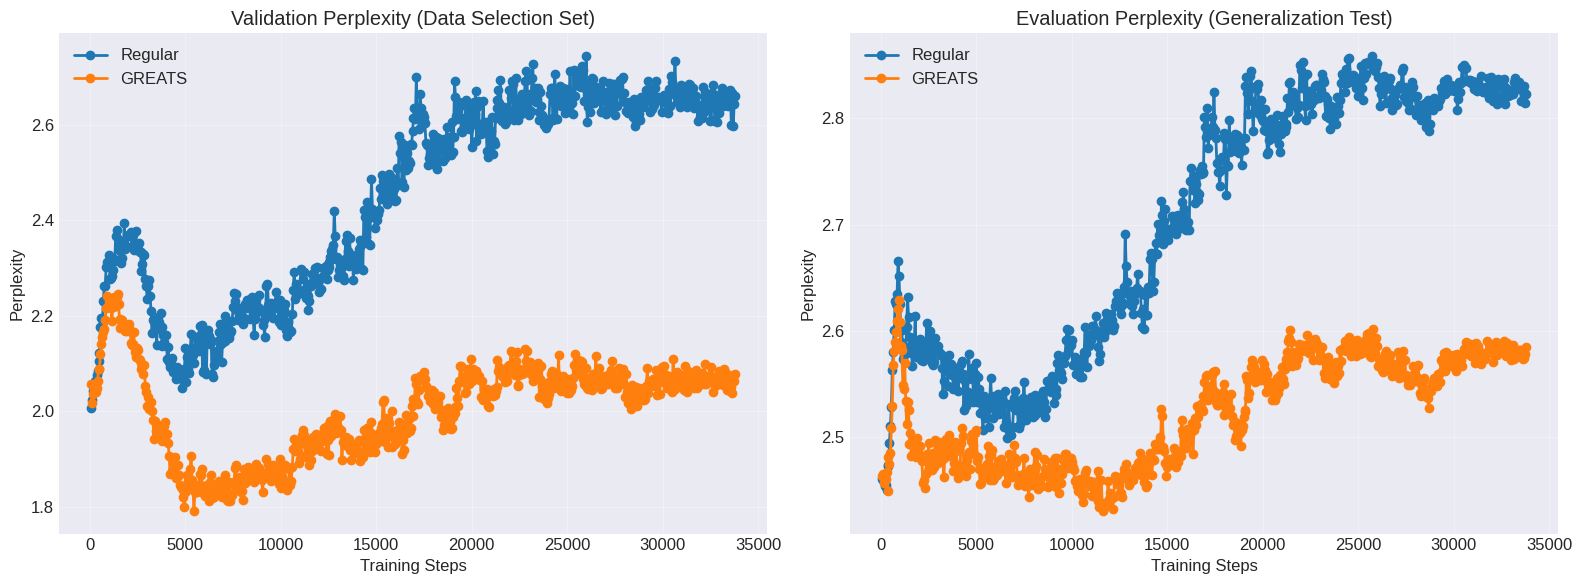

Plot saved to ./perplexity_comparison.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot validation perplexity (small set for data selection)
ax = axes[0]
for name, data in results.items():
    ax.plot(data['steps'], data['val_perplexity'], label=name, marker='o', linewidth=2)
ax.set_xlabel('Training Steps')
ax.set_ylabel('Perplexity')
ax.set_title('Validation Perplexity (Data Selection Set)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot evaluation perplexity (large held-out set)
ax = axes[1]
for name, data in results.items():
    ax.plot(data['steps'], data['eval_perplexity'], label=name, marker='o', linewidth=2)
ax.set_xlabel('Training Steps')
ax.set_ylabel('Perplexity')
ax.set_title('Evaluation Perplexity (Generalization Test)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./perplexity_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to ./perplexity_comparison.png")

## Compare Final Performance

In [4]:
# Print final results
print("\n=== Final Perplexity Results ===")
print(f"{'Method':<15} {'Val Perplexity':<20} {'Eval Perplexity':<20}")
print("-" * 55)

for name, data in results.items():
    final_val = data['val_perplexity'][-1]
    final_eval = data['eval_perplexity'][-1]
    print(f"{name:<15} {final_val:<20.4f} {final_eval:<20.4f}")


=== Final Perplexity Results ===
Method          Val Perplexity       Eval Perplexity     
-------------------------------------------------------
Regular         2.6597               2.8226              
GREATS          2.0789               2.5849              


## Plot Improvement Over Baseline

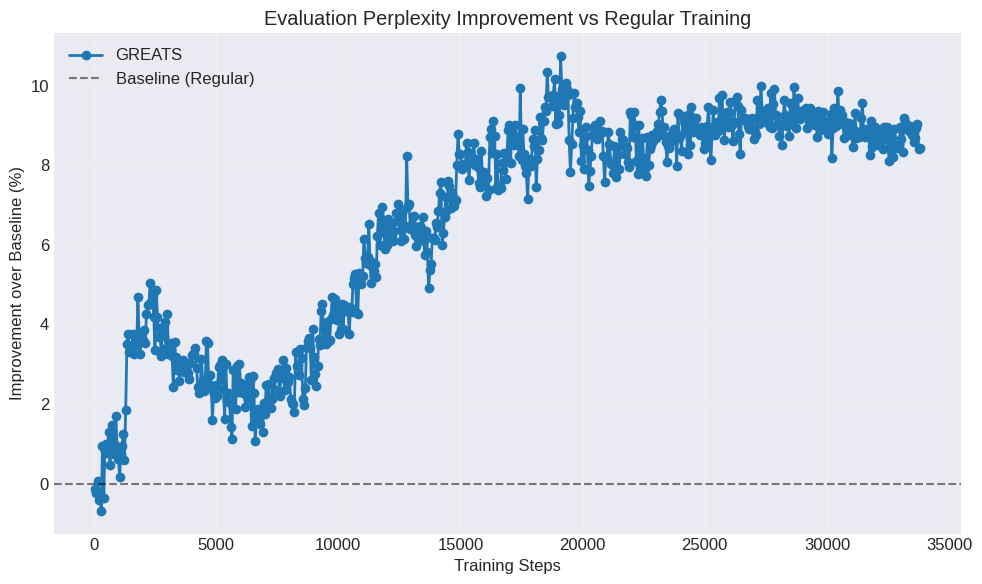

Plot saved to ./perplexity_improvement.png


In [5]:
# If you have a baseline (e.g., 'Regular'), compute relative improvement
if 'Regular' in results and len(results) > 1:
    baseline = results['Regular']

    plt.figure(figsize=(10, 6))

    for name, data in results.items():
        if name == 'Regular':
            continue

        # Compute percentage improvement on evaluation set
        # Lower perplexity is better, so improvement = (baseline - current) / baseline * 100
        improvement = (baseline['eval_perplexity'] - data['eval_perplexity']) / baseline['eval_perplexity'] * 100

        plt.plot(data['steps'], improvement, label=name, marker='o', linewidth=2)

    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Baseline (Regular)')
    plt.xlabel('Training Steps')
    plt.ylabel('Improvement over Baseline (%)')
    plt.title('Evaluation Perplexity Improvement vs Regular Training')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('./perplexity_improvement.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Plot saved to ./perplexity_improvement.png")

## Load MMLU Accuracy Results (if available)

In [6]:
# Load MMLU results if available
mmlu_experiments = {
    'Regular': './out/REGULAR-llama3-1b-p-lora-seed3/mmlu_results.json',
    'GREATS': './out/GREATS-llama3-1b-p-lora-seed3/mmlu_results.json',
}

mmlu_results = {}
for name, path in mmlu_experiments.items():
    if Path(path).exists():
        with open(path, 'r') as f:
            mmlu_results[name] = json.load(f)
        print(f"Loaded MMLU results for {name}")

if mmlu_results:
    print("\n=== MMLU Accuracy Results ===")
    print(f"{'Method':<15} {'Subject':<15} {'Accuracy':<15} {'Correct/Total'}")
    print("-" * 60)

    for name, data in mmlu_results.items():
        accuracy = data['accuracy']
        subject = data.get('subject', 'N/A')
        correct = data.get('num_correct', 'N/A')
        total = data.get('num_total', 'N/A')
        print(f"{name:<15} {subject:<15} {accuracy:<15.4f} {correct}/{total}")

    # Bar chart of accuracies
    plt.figure(figsize=(10, 6))
    names = list(mmlu_results.keys())
    accuracies = [mmlu_results[name]['accuracy'] for name in names]

    plt.bar(names, accuracies, alpha=0.7, edgecolor='black')
    plt.ylabel('Accuracy')
    plt.title('MMLU Accuracy Comparison')
    plt.ylim([0, 1])
    plt.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for i, (name, acc) in enumerate(zip(names, accuracies)):
        plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('./mmlu_accuracy_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Plot saved to ./mmlu_accuracy_comparison.png")
else:
    print("\nNo MMLU results found. Run evaluate_mmlu.py to generate them.")


No MMLU results found. Run evaluate_mmlu.py to generate them.
